#### Step 1: Import Libraries & Load the dataset

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
# Load Dataset
df = pd.read_csv("clean_layoff.csv", sep=";") 

# First 5 Rows
df.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Included Health,SF Bay Area,NaN,2022-07-25,0.06,Healthcare,https://www.fiercehealthcare.com/digital-healt...,Series E,272,United States,7/26/2022
1,&Open,"Dublin, Non-U.S.",9.0,2022-11-17,0.09,Marketing,https://www.irishtimes.com/technology/2022/11/...,Series A,35,Ireland,12/1/2022
2,#Paid,"Toronto, Non-U.S.",19.0,2023-01-27,0.17,Marketing,https://betakit.com/as-big-tech-makes-mass-lay...,Series B,21,Canada,1/28/2023
3,100 Thieves,Los Angeles,12.0,2022-07-13,NaN,Consumer,https://www.dexerto.com/esports/100-thieves-la...,Series C,120,United States,7/18/2022
4,10X Genomics,SF Bay Area,100.0,2022-08-04,0.08,Healthcare,https://www.genomeweb.com/business-news/10x-ge...,Post-IPO,242,United States,8/4/2022


In [3]:
# Dataset shape
print("Rows and Columns:", df.shape) 

Rows and Columns: (3167, 11)


In [4]:
# Dataset info
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 3167 entries, 0 to 3166
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              3167 non-null   str    
 1   location             3167 non-null   str    
 2   total_laid_off       2495 non-null   float64
 3   date                 3167 non-null   str    
 4   percentage_laid_off  2398 non-null   float64
 5   industry             3166 non-null   str    
 6   source               3167 non-null   str    
 7   stage                3166 non-null   str    
 8   funds_raised         3167 non-null   int64  
 9   country              3166 non-null   str    
 10  date_added           3167 non-null   str    
dtypes: float64(2), int64(1), str(8)
memory usage: 759.1 KB


#### Step 2: Data Cleaning & Missing value analysis

In [5]:
# Checking missing values
missing_values = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage.round(2)
})

missing_df.sort_values(by='Missing Values', ascending=False) 

,Missing Values,Percentage (%)
percentage_laid_off,769,24.28
total_laid_off,672,21.22
industry,1,0.03
country,1,0.03
stage,1,0.03
location,0,0.00
company,0,0.00
source,0,0.00
date,0,0.00
funds_raised,0,0.00


In [6]:
# Checking duplicate rows 
print("Duplicate Rows:", df.duplicated().sum()) 

Duplicate Rows: 0


In [7]:
# Converting date column to datetime

df['date'] = pd.to_datetime(df['date'])

# Creating Year and Month columns 
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month_name()

print(df[['date','Year','Month']].head()) 

        date  Year     Month
0 2022-07-25  2022      July
1 2022-11-17  2022  November
2 2023-01-27  2023   January
3 2022-07-13  2022      July
4 2022-08-04  2022    August


#### Step 3: Basic Dataset Summary 

In [ ]:
print("Total Records:", len(df))
print("Unique Companies:", df['company'].nunique())
print("Unique Industries:", df['industry'].nunique())
print("Unique Countries:", df['country'].nunique())

print("\nDate Range:")
print("From:", df['date'].min())
print("To:", df['date'].max())

print("\nTotal Employees Laid Off:")
print(df['total_laid_off'].sum())  

Total Records: 3167
Unique Companies: 2171
Unique Industries: 30
Unique Countries: 57

Date Range:
From: 2020-03-11 00:00:00
To: 2025-12-11 00:00:00

Total Employees Laid Off:
685227.0


#### Step 4: Yearly Layoffs Analysis 

Year
2020     70735.0
2021     15810.0
2022    150541.0
2023    213725.0
2024    128592.0
2025    105824.0
Name: total_laid_off, dtype: float64


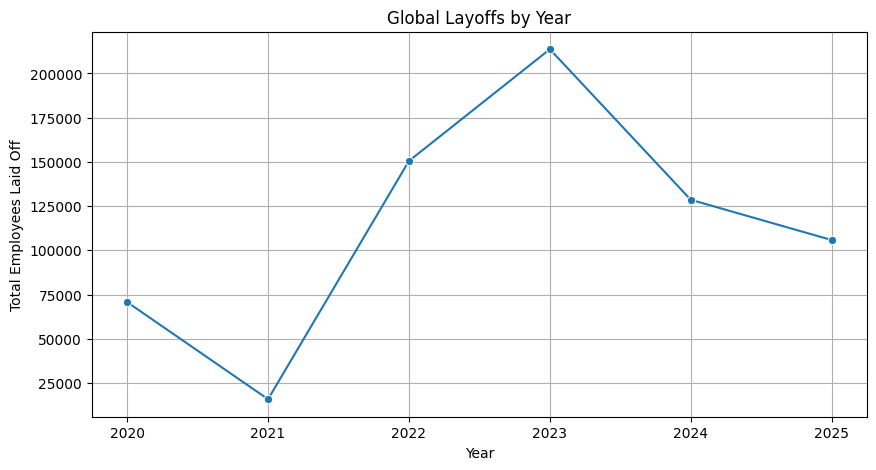

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Total layoffs by year
yearly_layoffs = (
    df.groupby('Year')['total_laid_off']
      .sum()
      .sort_index()
)

print(yearly_layoffs)

plt.figure(figsize=(10,5)) 
sns.lineplot(
    x=yearly_layoffs.index,
    y=yearly_layoffs.values,
    marker='o'
)

plt.title('Global Layoffs by Year')
plt.xlabel('Year')
plt.ylabel('Total Employees Laid Off') 
plt.grid(True)
plt.show()

Interpretation for Report: 
Global layoffs remained relatively low in 2021 but increased dramatically in 2022 and reached their peak in 2023 with over 213,000 employees laid off. After 2023, layoffs showed a declining trend, suggesting that organizations gradually stabilized their workforce following large-scale restructuring efforts.

Conclusion: 
The period from 2022 to 2023 represents the most severe phase of workforce reductions in the dataset.

#### Step 5: Top 10 Companies by Layoffs

company
Intel         43115.0
Amazon        41940.0
Microsoft     30055.0
Meta          25300.0
Salesforce    16525.0
Cisco         14521.0
Tesla         14500.0
Google        13697.0
SAP           11000.0
Ericsson       8500.0
Name: total_laid_off, dtype: float64


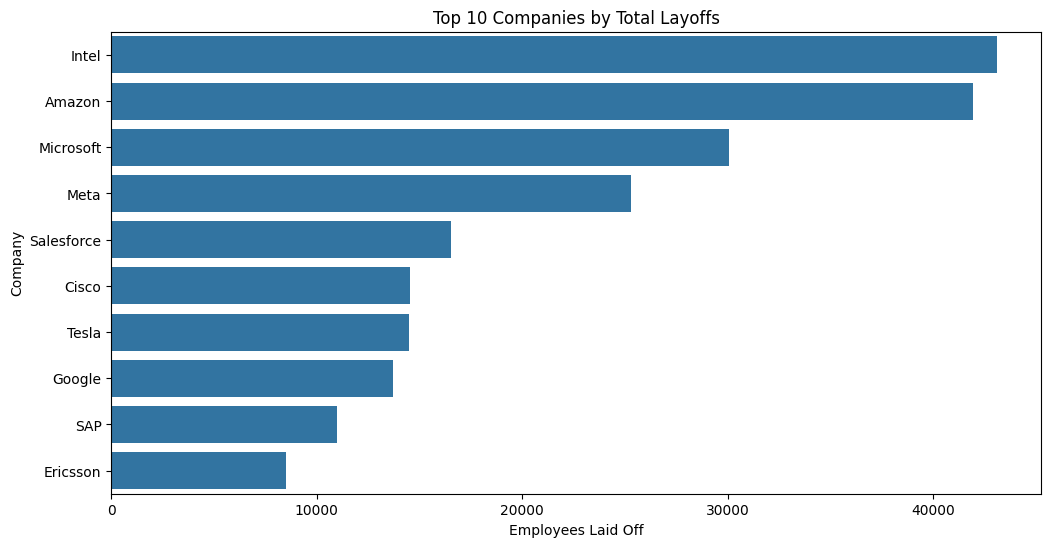

In [10]:
top_companies = (
    df.groupby('company')['total_laid_off']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
print(top_companies)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_companies.values,
    y=top_companies.index
) 
plt.title('Top 10 Companies by Total Layoffs')
plt.xlabel('Employees Laid Off')
plt.ylabel('Company') 
plt.show()

Report Interpretation: 
Intel recorded the highest number of layoffs, followed closely by Amazon and Microsoft. Most of the top ten companies belong to the technology sector, indicating that tech firms were significantly impacted despite their strong market presence and substantial financial resources.

Key Business Insight: 
The concentration of layoffs among major technology companies suggests that workforce reductions were driven not only by financial challenges but also by strategic restructuring, cost optimization, and changing market conditions.

#### Step 6: Industry-wise Layoffs Analysis

industry
Retail            85222.0
Other             76495.0
Consumer          74105.0
Transportation    62957.0
Hardware          58363.0
Food              47351.0
Finance           43617.0
Healthcare        24701.0
Sales             21087.0
Infrastructure    20590.0
Name: total_laid_off, dtype: float64


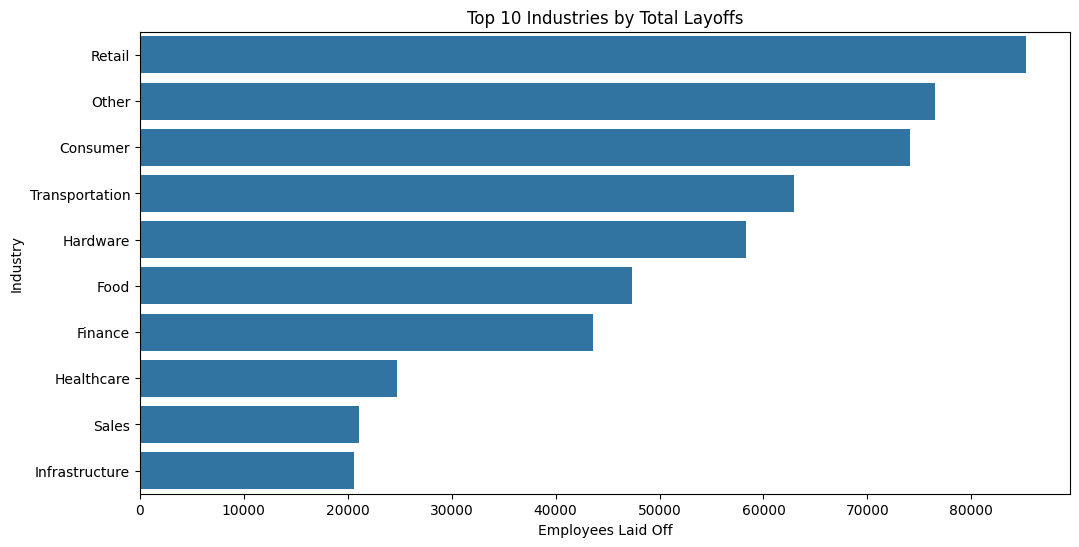

In [11]:
top_industries = (
    df.groupby('industry')['total_laid_off']
      .sum()
      .sort_values(ascending=False)
      .head(10)
) 
print(top_industries)

plt.figure(figsize=(12,6)) 
sns.barplot(
    x=top_industries.values,
    y=top_industries.index
) 
plt.title('Top 10 Industries by Total Layoffs')
plt.xlabel('Employees Laid Off')
plt.ylabel('Industry') 
plt.show()

Report Interpretation: 
The Retail industry experienced the highest number of layoffs, affecting more than 85,000 employees. Consumer, Transportation, and Hardware sectors were also heavily impacted. These industries are highly sensitive to changes in consumer demand, supply chain disruptions, and economic uncertainty.

Key Business Insight: 
While technology companies dominate the list of individual companies with large layoffs, the Retail sector experienced the greatest overall workforce reduction at the industry level. This suggests that layoffs were widespread across multiple sectors rather than being limited to technology alone.

EDA Observation Section:
The distribution of layoffs across industries indicates that economic challenges affected both traditional and modern industries. Retail and Consumer sectors experienced the largest workforce reductions, highlighting the impact of changing consumer behavior and market conditions on employment.

#### Step 7: Country-wise Analysis

country
United States     490850.0
India              55431.0
Germany            30230.0
United Kingdom     18707.0
Sweden             17894.0
Canada             15143.0
Brazil              9026.0
Israel              8388.0
China               6205.0
Singapore           5343.0
Name: total_laid_off, dtype: float64


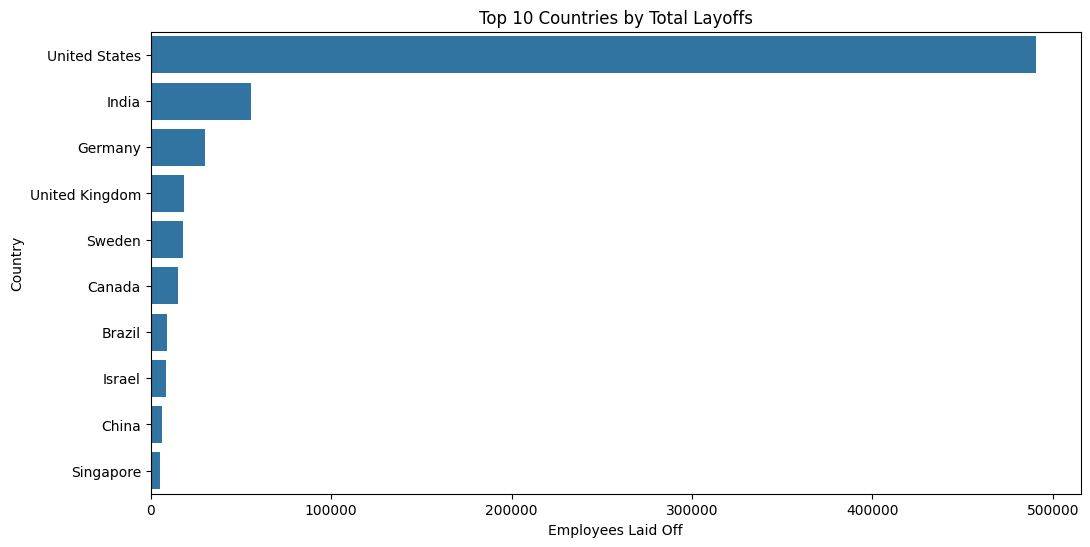

In [12]:
top_countries = (
    df.groupby('country')['total_laid_off']
      .sum()
      .sort_values(ascending=False)
      .head(10)
) 
print(top_countries)

plt.figure(figsize=(12,6)) 
sns.barplot(
    x=top_countries.values,
    y=top_countries.index
) 
plt.title('Top 10 Countries by Total Layoffs')
plt.xlabel('Employees Laid Off')
plt.ylabel('Country') 
plt.show()

In [13]:
us_share = (490850 / 685227) * 100
print(round(us_share, 2))

71.63


Report Interpretation: 
The United States experienced by far the highest number of layoffs, accounting for approximately 72% of all layoffs recorded in the dataset. India ranked second, followed by Germany and the United Kingdom. 

Key Business Insight: 
The dominance of layoffs in the United States reflects the concentration of major technology, retail, and startup companies within the country. Economic slowdowns and corporate restructuring in the U.S. therefore had a significant impact on global layoff statistics.

#### Step 8: Percentage Layoff Distribution

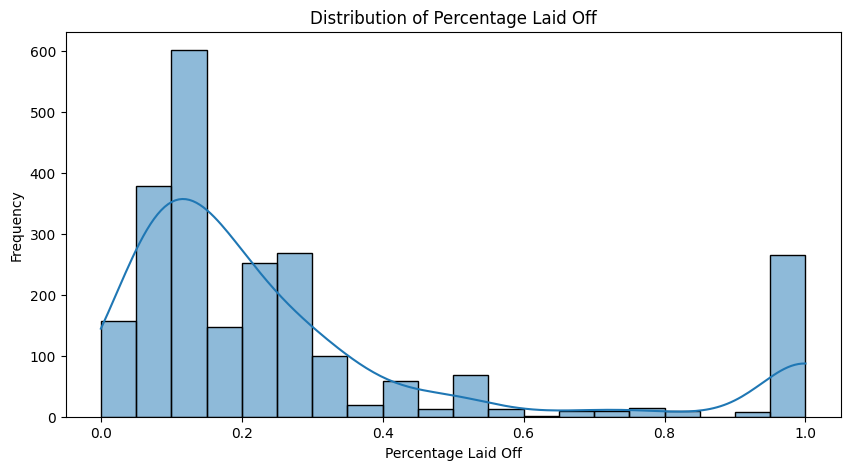

count    2398.000000
mean        0.280816
std         0.290316
min         0.000000
25%         0.100000
50%         0.170000
75%         0.300000
max         1.000000
Name: percentage_laid_off, dtype: float64


In [14]:
# This helps answer: "Were most layoffs small workforce reductions or complete company shutdowns?"
plt.figure(figsize=(10,5)) 
sns.histplot(
    df['percentage_laid_off'].dropna(),
    bins=20,
    kde=True
) 
plt.title('Distribution of Percentage Laid Off')
plt.xlabel('Percentage Laid Off')
plt.ylabel('Frequency') 
plt.show()

print(df['percentage_laid_off'].describe())

Report Interpretation:
Most companies laid off a relatively small portion of their workforce. The median layoff percentage is 17%, meaning half of the reported companies reduced their workforce by less than 17%. 
However, the histogram shows a second peak near 100%, indicating that a significant number of companies laid off their entire workforce.

Key Business Insight: 
The layoff distribution is strongly right-skewed. While most organizations conducted partial workforce reductions, a notable number of companies experienced complete shutdowns, resulting in 100% layoffs.

In [15]:
full_shutdowns = df[df['percentage_laid_off'] == 1]

print("Companies with 100% layoffs:", len(full_shutdowns))

full_shutdowns[['company','industry','country']].head(20)

Companies with 100% layoffs: 263


,company,industry,country
42,Advisor Credit Exchange,Finance,United States
49,Ahead,Healthcare,United States
54,Airlift,Logistics,Pakistan
71,Akudo,Finance,India
88,Alza,Finance,United States
101,Amicole,Retail,United States
107,Amplero,Marketing,United States
111,Anar,Marketing,India
119,ANS Commerce,Retail,India
130,AppHarvest,Food,United States


Report Interpretation: 

A total of 263 companies reported laying off their entire workforce. These cases indicate that workforce reductions were not limited to cost-cutting measures but often reflected complete business closures or operational shutdowns.

Key Business Insight: 

The presence of 263 full-shutdown events highlights the severity of economic pressures faced by some organizations. These shutdowns occurred across multiple industries, including Finance, Retail, Healthcare, Transportation, and Logistics, demonstrating that no sector was entirely immune to workforce disruptions.

#### Step 9: Funding Raised vs Total Layoffs

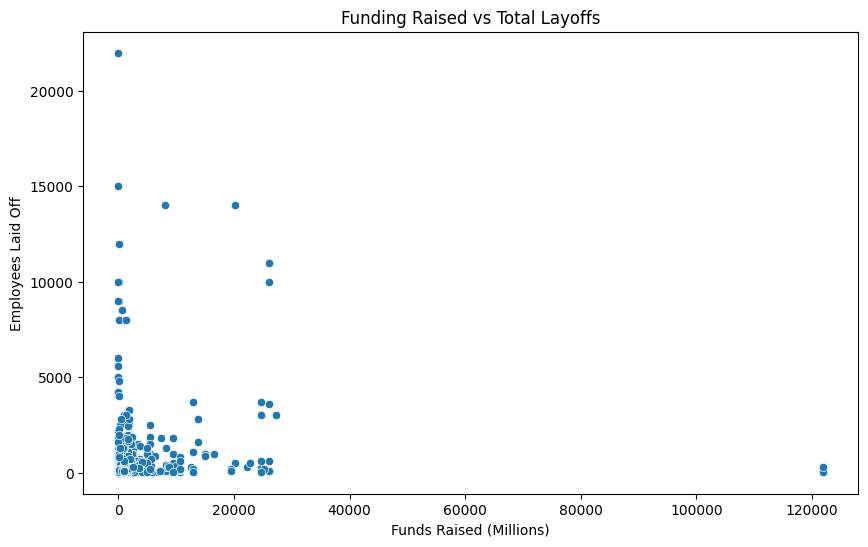

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='funds_raised',
    y='total_laid_off'
)
plt.title('Funding Raised vs Total Layoffs')
plt.xlabel('Funds Raised (Millions)')
plt.ylabel('Employees Laid Off')
plt.show()

In [17]:
correlation = df[['funds_raised','total_laid_off']].corr() 
print(correlation)

                funds_raised  total_laid_off
funds_raised        1.000000        0.105334
total_laid_off      0.105334        1.000000


Interpretation:
A correlation of 0.105 indicates a very weak positive relationship between funding raised and the number of employees laid off.

In practical terms:
Companies that raised more funding were not significantly less likely to conduct layoffs.

The scatter plot also supports this conclusion:
- Most points are clustered near the bottom.
- Several highly funded companies still reported substantial layoffs.
- There is no clear upward or downward trend. 

Key Business Insight: 
Access to large amounts of funding did not guarantee workforce stability. External economic conditions, changing business priorities, and operational restructuring appear to have played a more important role in layoff decisions than funding levels alone.

#### Step 10: Correlation Heatmap

                     total_laid_off  percentage_laid_off  funds_raised
total_laid_off             1.000000            -0.047170      0.105334
percentage_laid_off       -0.047170             1.000000     -0.078746
funds_raised               0.105334            -0.078746      1.000000


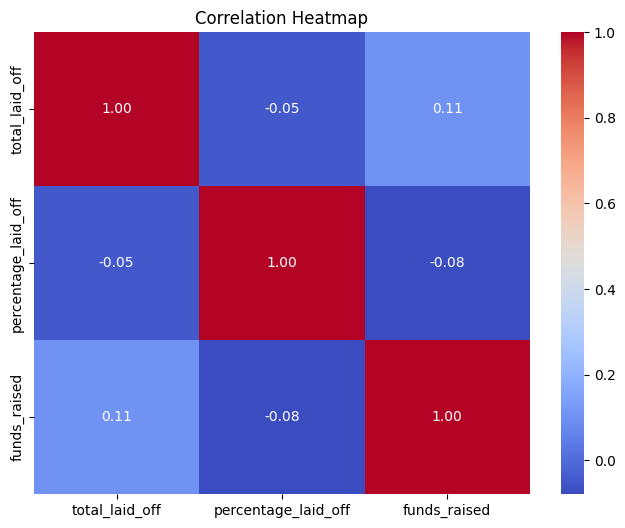

In [18]:
numeric_cols = df[['total_laid_off',
                   'percentage_laid_off',
                   'funds_raised']]

corr_matrix = numeric_cols.corr() 
print(corr_matrix)

plt.figure(figsize=(8,6)) 
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
) 
plt.title('Correlation Heatmap')
plt.show()

Interpretation

Total Laid Off vs Percentage Laid Off (-0.047):
There is almost no relationship between the number of employees laid off and the percentage of workforce laid off. Large companies can lay off thousands of employees while still affecting a small percentage of their workforce.

Total Laid Off vs Funds Raised (0.105):
A very weak positive correlation exists between funding raised and layoffs, indicating that funding levels alone do not explain workforce reductions.

Percentage Laid Off vs Funds Raised (-0.079):
There is virtually no relationship between company funding and the percentage of employees laid off.